# Problématique

## Formulation du problème

Dans ce notebook, le problème est formulé comme une **classification multiclasse** 
à partir d'images médicales.

L'objectif n'est pas uniquement de détecter la présence de pneumonie, mais de 
**distinguer trois états cliniques distincts** : poumon normal, pneumonie 
bactérienne et pneumonie virale — distinction qui oriente directement le 
traitement antibiotique ou antiviral.

## Objectifs de modélisation

- **Définir les classes** : Normal (0), Bactérienne (1), Virale (2)
- **Entraîner un modèle CNN** par Transfer Learning sur EfficientNetB0
- **Produire une explication visuelle** via Grad-CAM pour chaque prédiction
- **Comparer les performances** par classe avec des métriques adaptées

## Cibles du problème

La variable cible est la classe de l'image :
1. `NORMAL` : poumon sain
2. `BACTERIA` : pneumonie bactérienne
3. `VIRUS` : pneumonie virale

## Déséquilibre des classes

Le dataset présente un déséquilibre marqué entre les classes — explicitement 
pris en compte via des class weights pendant l'entraînement.

## Métrique principale

La métrique principale est l'**AUC-ROC par classe** (approche One-vs-Rest), 
car elle mesure la capacité du modèle à discriminer chaque classe 
indépendamment du seuil de décision.

L'accuracy seule n'est pas suffisante sur un dataset déséquilibré.

# Analyse Exploratoire des Données

#### Vérification GPU + imports

In [2]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from PIL import Image
import shutil 

# Vérifier le GPU
print(f'GPU Disponible :{tf.config.list_physical_devices('GPU')}')
print(f'Version disponible : {tf.__version__}')

2026-04-25 20:38:59.279254: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777149539.502857      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777149539.567677      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777149540.100973      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777149540.101005      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777149540.101009      55 computation_placer.cc:177] computation placer alr

GPU Disponible :[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Version disponible : 2.19.0


#### Vérification du dataset

In [3]:

base_dir = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"

print(os.listdir(base_dir))
for val in os.listdir(base_dir):
    pd.value_counts(val)


['chest_xray', '__MACOSX', 'val', 'test', 'train']


/tmp/ipykernel_55/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: value_counts with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  pd.value_counts(val)
/tmp/ipykernel_55/3632799331.py:5: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  pd.value_counts(val)
/

#### Bacteria vs Virus

In [4]:
pneumonia = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train/PNEUMONIA/'

bacteria = [f for f in os.listdir(pneumonia) if 'bacteria' in f]

virus = [f for f in os.listdir(pneumonia) if 'virus' in f]
print(len(bacteria))
print(len(virus))



2530
1345


#### Distribution des 3 classes

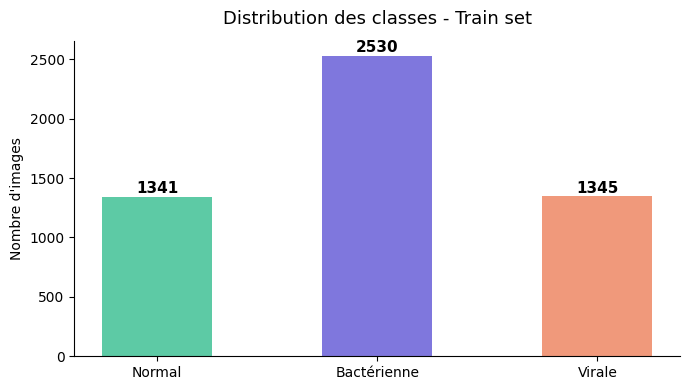

In [5]:
normal_n    = len(os.listdir(os.path.join(base_dir, "train", "NORMAL")))
bacteria_n  = len(bacteria)
virus_n     = len(virus)

classes = ["Normal", "Bactérienne", "Virale"]
counts  = [normal_n, bacteria_n, virus_n]
colors  = ["#5DCAA5", "#7F77DD", "#F0997B"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(classes, counts, color=colors, width=0.5)
ax.set_title("Distribution des classes - Train set", fontsize=13, pad=12)
ax.set_ylabel("Nombre d'images")

for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', fontsize=11, fontweight='bold')

sns.despine()
plt.tight_layout()
plt.savefig("distribution_classes.png", dpi=150) 
plt.show()

#### Visualiser des images des 3 classes côte à côte

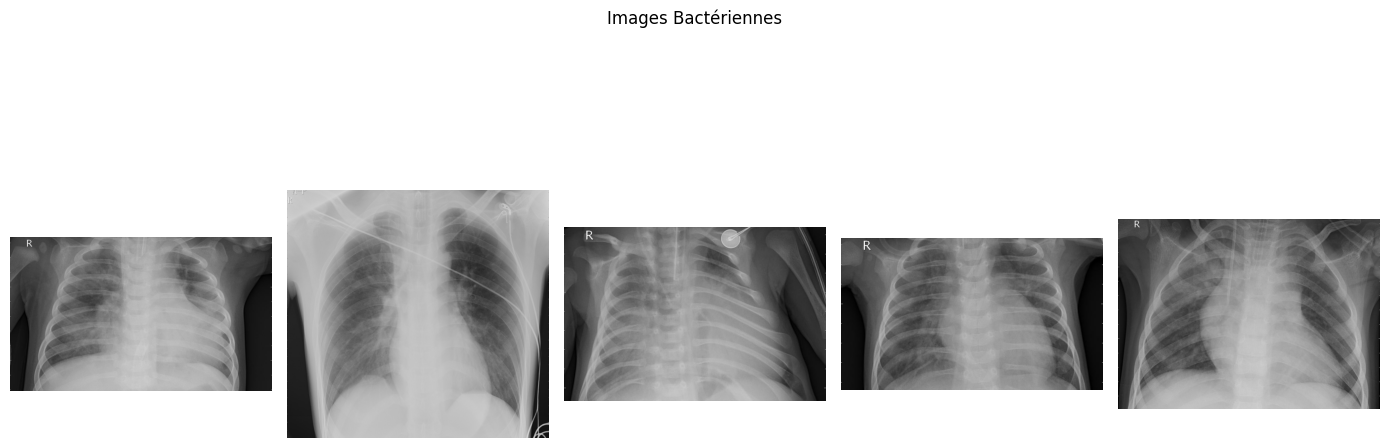

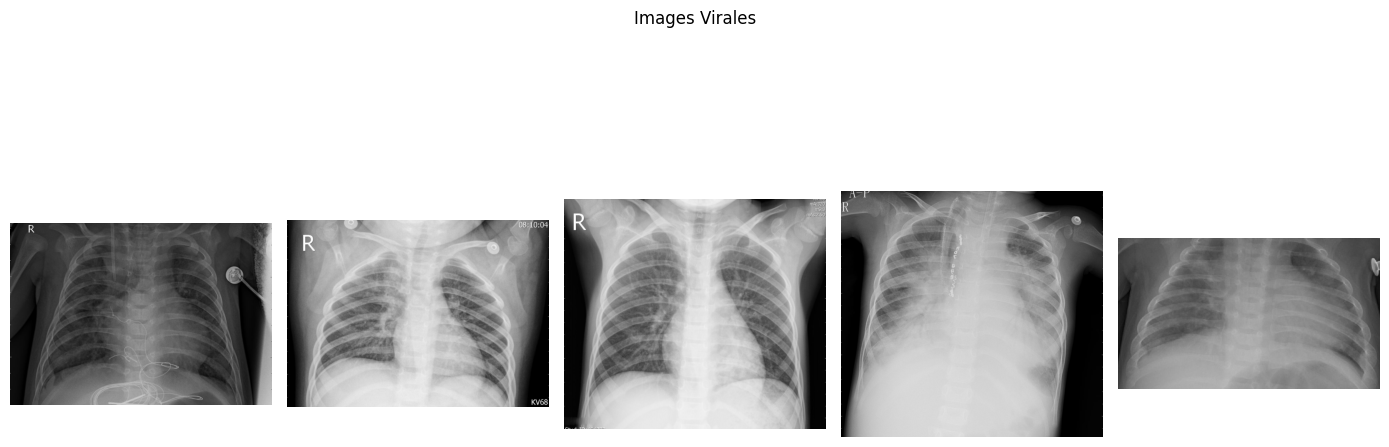

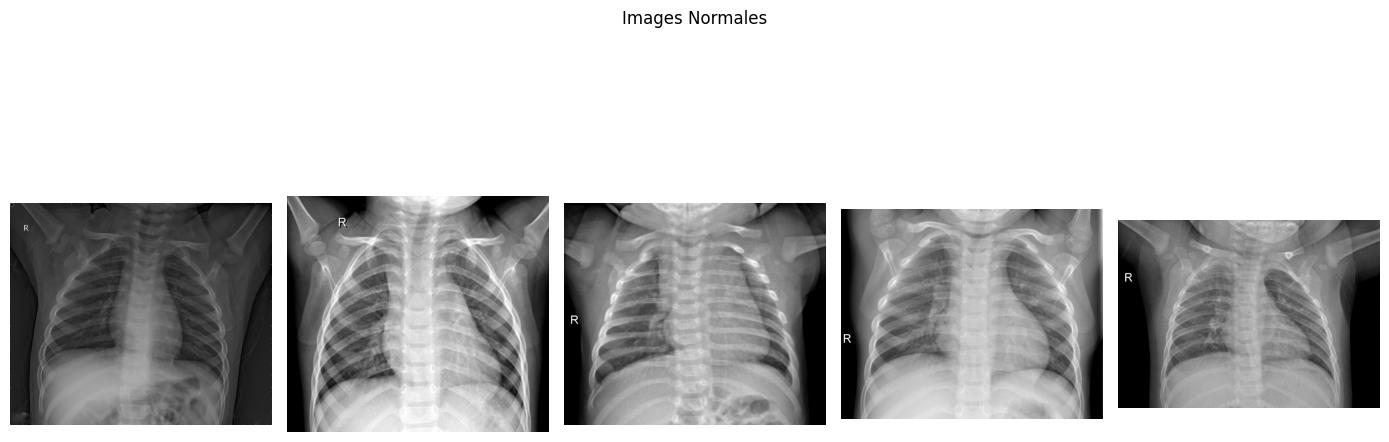

In [6]:
train_dir = os.path.join(base_dir, "train")
normal = os.path.join(train_dir, "NORMAL")
normal_files = os.listdir(normal)


def afficher_images(dossier, fichiers, titre, n=5):
    fig, ax = plt.subplots(1, n, figsize=(14, 6))
    
    for i in range(n):
        chemin = os.path.join(dossier, fichiers[i])  # chemin complet
        img = Image.open(chemin).convert("RGB")      # ouvrir image
        
        ax[i].imshow(img)                            # afficher
        ax[i].axis('off')                            # enlever axes
    
    fig.suptitle(titre)
    plt.tight_layout()
    plt.show()

afficher_images(pneumonia, bacteria, "Images Bactériennes")
afficher_images(pneumonia, virus, "Images Virales")
afficher_images(normal, normal_files, "Images Normales")

#### Vérifier la variabilité des tailles d'images

In [7]:
widths, heights = [], []

# Échantillon d'images
all_files = (
    [(normal, f) for f in normal_files[:34]] +
    [(pneumonia, f) for f in bacteria[:33]] +
    [(pneumonia, f) for f in virus[:33]]
)

for folder, fname in all_files:
    try:
        chemin = os.path.join(folder, fname)
        w, h = Image.open(chemin).size
        
        widths.append(w)
        heights.append(h)
    except:
        pass

print(f"Largeur  - min: {min(widths)}  max: {max(widths)}  moyenne: {int(np.mean(widths))}")
print(f"Hauteur  - min: {min(heights)} max: {max(heights)} moyenne: {int(np.mean(heights))}")

Largeur  - min: 703  max: 2400  moyenne: 1350
Hauteur  - min: 457 max: 2121 moyenne: 1003


# Pipeline de données

#### Réorganiser les fichiers

In [8]:
import os
import shutil

base = '/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray'
dest = '/kaggle/working/chest_xray'

# Créer tous les dossiers
for split in ['train', 'val', 'test']:
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        os.makedirs(f"{dest}/{split}/{cls}", exist_ok=True)

# Copier NORMAL
for split in ['train', 'val', 'test']:
    source = f"{base}/{split}/NORMAL"
    destination = f"{dest}/{split}/NORMAL"
    for fichier in os.listdir(source):
        shutil.copy(os.path.join(source, fichier), destination)

# Trier PNEUMONIA en BACTERIA et VIRUS
for split in ['train', 'val', 'test']:
    source = f"{base}/{split}/PNEUMONIA"
    for fichier in os.listdir(source):
        if 'bacteria' in fichier.lower():
            shutil.copy(os.path.join(source, fichier), f"{dest}/{split}/BACTERIA")
        elif 'virus' in fichier.lower():
            shutil.copy(os.path.join(source, fichier), f"{dest}/{split}/VIRUS")

# Vérifier la structure
print("VÉRIFICATION DE LA STRUCTURE\n")
for split in ['train', 'val', 'test']:
    print(f"{split.upper()}/")
    for cls in ['NORMAL', 'BACTERIA', 'VIRUS']:
        n = len(os.listdir(f"{dest}/{split}/{cls}"))
        print(f"  {cls} : {n} images")
    print()

VÉRIFICATION DE LA STRUCTURE

TRAIN/
  NORMAL : 1342 images
  BACTERIA : 2530 images
  VIRUS : 1345 images

VAL/
  NORMAL : 9 images
  BACTERIA : 8 images
  VIRUS : 0 images

TEST/
  NORMAL : 234 images
  BACTERIA : 242 images
  VIRUS : 148 images



#### Créer les datasets avec image_dataset_from_directory (3 classes)

In [9]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/train',
    validation_split=0.2,
    subset='training',
    image_size=(224, 224),
    batch_size=32,
    shuffle=True,
    seed=42
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/train',
    validation_split=0.2,
    subset='validation',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,
    seed=42
)

Found 5216 files belonging to 3 classes.
Using 4173 files for training.


I0000 00:00:1777149627.811233      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777149627.817180      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 5216 files belonging to 3 classes.
Using 1043 files for validation.


In [10]:
print(train_ds.class_names)
# ['BACTERIA', 'NORMAL', 'VIRUS']

# Voir la forme d'un batch
for images, labels in train_ds.take(1):
    print(images.shape)  # (32, 224, 224, 3)
    print(labels.shape)  # (32,)
    print(labels)        # [0, 1, 2, 0, 1, ...]

['BACTERIA', 'NORMAL', 'VIRUS']
(32, 224, 224, 3)
(32,)
tf.Tensor([2 1 0 1 0 0 0 1 1 2 0 2 2 1 2 0 0 0 0 1 0 1 1 1 0 1 0 0 1 2 1 2], shape=(32,), dtype=int32)


In [11]:
print(val_ds.class_names)

for images , labels in val_ds.take(1):
    print(images.shape)
    print(labels.shape)
    print(labels)

['BACTERIA', 'NORMAL', 'VIRUS']
(32, 224, 224, 3)
(32,)
tf.Tensor([2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2], shape=(32,), dtype=int32)


In [46]:
test_ds= tf.keras.utils.image_dataset_from_directory(
    '/kaggle/working/chest_xray/test',
    image_size=(224, 224),
    batch_size=32,
    shuffle=False,# car on a pas besoin  de modifier l'ordre popur val et test 
    seed=42
)


Found 624 files belonging to 3 classes.


#### Déséquilibre des classes

In [13]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Récupérer tous les labels du train
labels = []
for images, label_batch in train_ds:
    labels.extend(label_batch.numpy())

labels = np.array(labels)

# Calculer les poids
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

# Convertir en float Python (plus robuste avec Keras)
class_weight_dict = {int(i): float(w) for i, w in enumerate(class_weights)}
print(class_weight_dict)

{0: 0.6762275157997083, 1: 1.3400770712909442, 2: 1.290352504638219}


#### Optimisation du pipeline 

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

# EfficientNetB0 (tf.keras.applications) gère déjà le prétraitement attendu.
# On optimise ici le pipeline sans appliquer de normalization_layer externe.
train_ds = train_ds.cache().prefetch(AUTOTUNE)
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

# Transfer Learning

In [15]:
base_model = tf.keras.applications.EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False
print("Couches :", len(base_model.layers))

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Couches : 238


#### Construire la tête et assembler le modèle

In [16]:
from tensorflow.keras.layers import (Dense, Dropout, GlobalAveragePooling2D,
                                     RandomFlip, RandomRotation, RandomZoom)

model = tf.keras.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.build(input_shape=(None, 224, 224, 3))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,926 (16.07 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

#### Compilation

In [17]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=[
        'accuracy',
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=2, name='top2_acc')
    ]
)

#### Callbacks

In [18]:
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",  # format moderne
    monitor='val_loss',
    save_best_only=True
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2
)

In [19]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/15


E0000 00:00:1777149651.428146      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1777149654.166826     158 cuda_dnn.cc:529] Loaded cuDNN version 91002


131/131 ━━━━━━━━━━━━━━━━━━━━ 33s 153ms/step - accuracy: 0.6257 - loss: 0.8117 - top2_acc: 0.8925 - val_accuracy: 0.5973 - val_loss: 0.7405 - val_top2_acc: 0.9664 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 82ms/step - accuracy: 0.7404 - loss: 0.5982 - top2_acc: 0.9553 - val_accuracy: 0.6232 - val_loss: 0.7466 - val_top2_acc: 0.9549 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - accuracy: 0.7579 - loss: 0.5679 - top2_acc: 0.9623 - val_accuracy: 0.6711 - val_loss: 0.6534 - val_top2_acc: 0.9770 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.7663 - loss: 0.5492 - top2_acc: 0.9674 - val_accuracy: 0.6558 - val_loss: 0.6644 - val_top2_acc: 0.9837 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 11s 85ms/step - accuracy: 0.7740 - loss: 0.5410 - top2_acc: 0.9711 - val_accuracy: 0.6472 - val_loss: 0.6919 - val_top2_acc: 0.9933 - learning_rate: 0.0010
Epoch 6/15
131/131 ━━━━━━━━━━━

#### commentaire 

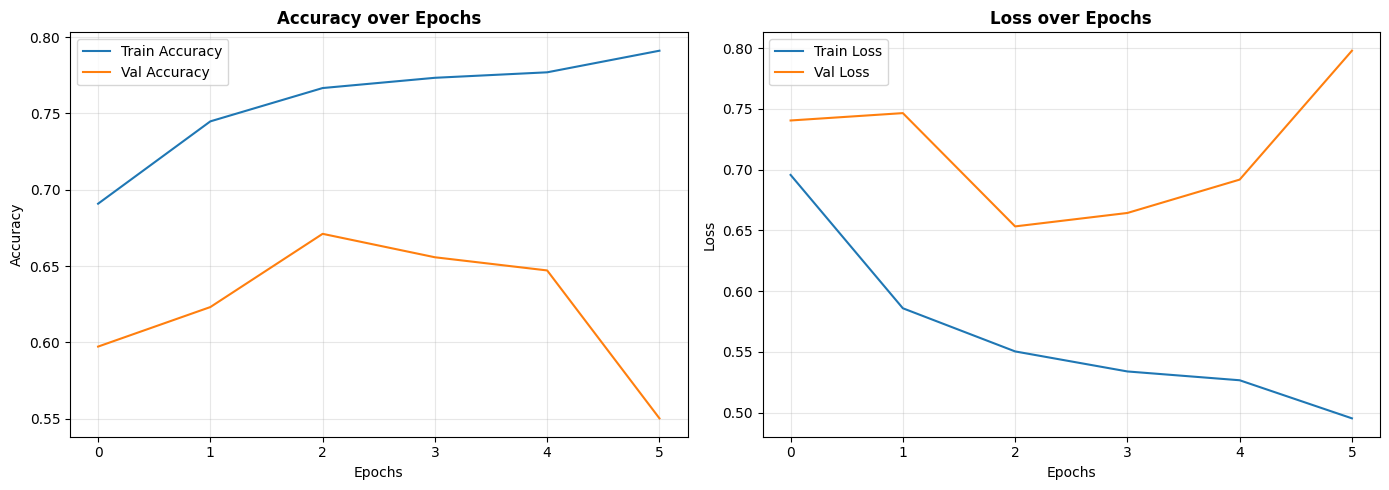

In [20]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy subplot
ax[0].plot(history.history['accuracy'], label='Train Accuracy')
ax[0].plot(history.history['val_accuracy'], label='Val Accuracy')
ax[0].set_title('Accuracy over Epochs', fontsize=12, fontweight='bold')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Loss subplot
ax[1].plot(history.history['loss'], label='Train Loss')
ax[1].plot(history.history['val_loss'], label='Val Loss')
ax[1].set_title('Loss over Epochs', fontsize=12, fontweight='bold')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150)
plt.show()

# Evaluation 

In [31]:
# 🔹 Charger le modèle
best_model = tf.keras.models.load_model("best_model.keras")

# 🔹 Récupérer les vraies classes
y_true = np.concatenate([y.numpy() for x, y in test_ds], axis=0)

# 🔹 Faire les prédictions (probabilités)
y_pred = best_model.predict(test_ds)

# 🔹 Convertir en classes
y_pred_classes = np.argmax(y_pred, axis=1)

# 🔹 Noms des classes (adapte si besoin)
class_names = ['BACTERIA', 'NORMAL', 'VIRUS']

print("🔹 Aperçu des probabilités (y_pred) :")
print(y_pred[:5])
print("\n")

print("🔹 Classes prédites (y_pred_classes) :")
print(y_pred_classes[:10])
print("\n")

print("🔹 Vraies classes (y_true) :")
print(y_true[:10])
print("\n")

print("🔹 Comparaison (True vs Pred) :")
for i in range(10):
    print(f"Image {i+1}: True = {class_names[y_true[i]]} | Pred = {class_names[y_pred_classes[i]]}")

print("\n")

print("🔹 Confiance du modèle :")
for i in range(10):
    confidence = np.max(y_pred[i])
    print(f"Image {i+1}: Pred = {class_names[y_pred_classes[i]]} ({confidence:.2f})")

20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 170ms/step
🔹 Aperçu des probabilités (y_pred) :
[[0.40030736 0.3526198  0.24707279]
 [0.80054337 0.00518625 0.19427037]
 [0.6836434  0.00241626 0.3139403 ]
 [0.8240272  0.00110057 0.1748722 ]
 [0.71143436 0.00118331 0.2873823 ]]


🔹 Classes prédites (y_pred_classes) :
[0 0 0 0 0 0 0 0 0 0]


🔹 Vraies classes (y_true) :
[0 0 0 0 0 0 0 0 0 0]


🔹 Comparaison (True vs Pred) :
Image 1: True = BACTERIA | Pred = BACTERIA
Image 2: True = BACTERIA | Pred = BACTERIA
Image 3: True = BACTERIA | Pred = BACTERIA
Image 4: True = BACTERIA | Pred = BACTERIA
Image 5: True = BACTERIA | Pred = BACTERIA
Image 6: True = BACTERIA | Pred = BACTERIA
Image 7: True = BACTERIA | Pred = BACTERIA
Image 8: True = BACTERIA | Pred = BACTERIA
Image 9: True = BACTERIA | Pred = BACTERIA
Image 10: True = BACTERIA | Pred = BACTERIA


🔹 Confiance du modèle :
Image 1: Pred = BACTERIA (0.40)
Image 2: Pred = BACTERIA (0.80)
Image 3: Pred = BACTERIA (0.68)
Image 4: Pred = BACTERIA (0.82)
Image 5: 

In [25]:
from sklearn.metrics import classification_report

ordered_labels = [1, 0, 2]
ordered_names = ['NORMAL', 'BACTERIA', 'VIRUS']

print('Classification Report:')
print(
    classification_report(
        y_true,
        y_pred_classes,  # ✅ ICI
        labels=ordered_labels,
        target_names=ordered_names,
        digits=4
    )
)

Classification Report:
              precision    recall  f1-score   support

      NORMAL     0.8951    0.5470    0.6790       234
    BACTERIA     0.8549    0.9008    0.8773       242
       VIRUS     0.5354    0.8176    0.6471       148

    accuracy                         0.7484       624
   macro avg     0.7618    0.7551    0.7345       624
weighted avg     0.7942    0.7484    0.7483       624



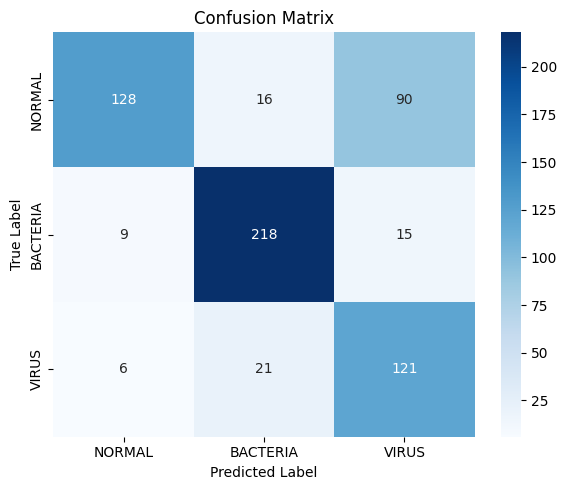

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

ordered_labels = [1, 0, 2]
ordered_names = ['NORMAL', 'BACTERIA', 'VIRUS']

cm = confusion_matrix(y_true, y_pred_classes, labels=ordered_labels)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=ordered_names,
    yticklabels=ordered_names
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [30]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import pandas as pd

# AUC-ROC global (One-vs-Rest)
auc_ovr_global = roc_auc_score(y_true, y_pred, multi_class='ovr')
print(f'Global AUC-ROC (OvR): {auc_ovr_global:.4f}')

# AUC-ROC per class in requested order: NORMAL, BACTERIA, VIRUS
ordered_labels = [1, 0, 2]
ordered_names = ['NORMAL', 'BACTERIA', 'VIRUS']

y_prob = y_pred

y_true_bin = label_binarize(y_true, classes=[0, 1, 2])
auc_per_class = {}
for class_id, class_name in zip(ordered_labels, ordered_names):
    auc_per_class[class_name] = roc_auc_score(y_true_bin[:, class_id], y_prob[:, class_id])

auc_df = pd.DataFrame(
    {'Class': list(auc_per_class.keys()), 'AUC_ROC_OvR': list(auc_per_class.values())}
).sort_values('AUC_ROC_OvR', ascending=False)

print('\nPer-class AUC-ROC (OvR):')
print(auc_df.to_string(index=False))



Global AUC-ROC (OvR): 0.9303

Per-class AUC-ROC (OvR):
   Class  AUC_ROC_OvR
BACTERIA     0.955768
  NORMAL     0.938779
   VIRUS     0.896448


In [32]:
# Afficher les 5 dernières couches d'EfficientNet
for layer in best_model.layers[3].layers[-5:]:
    print(layer.name, layer.output.shape)

block7a_project_conv (None, 7, 7, 320)
block7a_project_bn (None, 7, 7, 320)
top_conv (None, 7, 7, 1280)
top_bn (None, 7, 7, 1280)
top_activation (None, 7, 7, 1280)


In [44]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    
    base_model = model.get_layer('efficientnetb0')  # adapte si besoin

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,  # 🔥 IMPORTANT (inputs au pluriel)
        outputs=[
            base_model.get_layer(last_conv_layer_name).output,
            model.output
        ]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.reduce_max(heatmap)

    return heatmap.numpy(), pred_index.numpy()

In [38]:
def overlay_gradcam(img_array, heatmap, alpha=0.4):
    # Redimensionner la heatmap à 224x224
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    
    # Convertir en couleur (COLORMAP_JET = bleu→vert→rouge)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), 
        cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Image originale entre 0-255
    img = img_array[0].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    
    # Superposer
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

In [40]:
def overlay_gradcam(img_array, heatmap, alpha=0.4):
    # Redimensionner la heatmap à 224x224
    heatmap_resized = cv2.resize(heatmap, (224, 224))
    
    # Convertir en couleur (COLORMAP_JET = bleu→vert→rouge)
    heatmap_colored = cv2.applyColorMap(
        np.uint8(255 * heatmap_resized), 
        cv2.COLORMAP_JET
    )
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Image originale entre 0-255
    img = img_array[0].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)
    
    # Superposer
    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap_colored, alpha, 0)
    return superimposed

Image en bloc enregistree: gradcam_exports/gradcam_bloc_batch_test.png


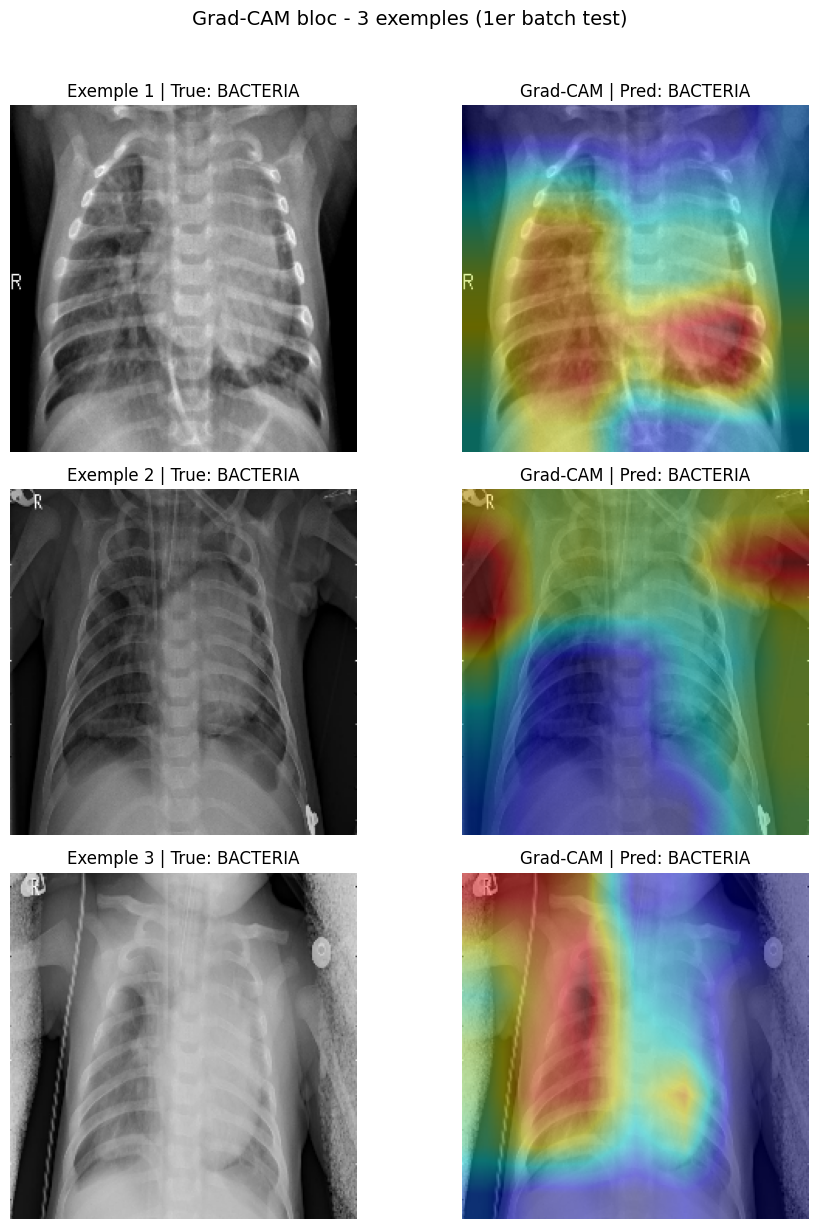

In [52]:
import os
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Charger le modèle
best_model = tf.keras.models.load_model("best_model.keras")

# Initialiser le modèle une fois (important avec Keras 3)
_ = best_model(tf.zeros((1, 224, 224, 3), dtype=tf.float32), training=False)

def make_gradcam_heatmap(img_array, model, last_conv_layer_name="top_conv"):
    base_model = model.get_layer("efficientnetb0")
    base_idx = model.layers.index(base_model)

    # Passer dans les couches avant EfficientNet (data augmentation)
    x = img_array
    for layer in model.layers[:base_idx]:
        x = layer(x, training=False)

    # Modèle intermédiaire sur EfficientNet uniquement
    conv_model = tf.keras.models.Model(
        inputs=base_model.input,
        outputs=[base_model.get_layer(last_conv_layer_name).output, base_model.output],
    )

    with tf.GradientTape() as tape:
        conv_outputs, x = conv_model(x, training=False)

        # Continuer dans la tête de classification
        for layer in model.layers[base_idx + 1:]:
            x = layer(x, training=False)

        predictions = x
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap = heatmap / (tf.reduce_max(heatmap) + tf.keras.backend.epsilon())

    return heatmap.numpy(), int(pred_index.numpy())

def overlay_gradcam(img_array, heatmap, alpha=0.4):
    img = img_array[0].numpy()
    if img.max() <= 1.0:
        img = (img * 255).astype(np.uint8)
    else:
        img = img.astype(np.uint8)

    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)

    superimposed = cv2.addWeighted(img, 1 - alpha, heatmap, alpha, 0)
    return superimposed

class_names = ["BACTERIA", "NORMAL", "VIRUS"]

# Sauvegarde en bloc pour 3 exemples du 1er batch de test
save_dir = "gradcam_exports"
os.makedirs(save_dir, exist_ok=True)

for images, labels in test_ds.take(1):
    n_show = min(3, images.shape[0])
    fig, axes = plt.subplots(n_show, 2, figsize=(10, 4 * n_show))
    if n_show == 1:
        axes = np.expand_dims(axes, axis=0)

    for i in range(n_show):
        img_array = tf.expand_dims(images[i], axis=0)
        heatmap, pred_idx = make_gradcam_heatmap(img_array, best_model)
        superimposed_img = overlay_gradcam(img_array, heatmap)
        true_idx = int(labels[i].numpy())

        axes[i, 0].imshow(images[i].numpy().astype(np.uint8))
        axes[i, 0].set_title(f"Exemple {i + 1} | True: {class_names[true_idx]}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(superimposed_img)
        axes[i, 1].set_title(f"Grad-CAM | Pred: {class_names[pred_idx]}")
        axes[i, 1].axis("off")

    fig.suptitle("Grad-CAM bloc - 3 exemples (1er batch test)", fontsize=14, y=1.02)
    fig.tight_layout()

    save_path = os.path.join(save_dir, "gradcam_bloc_batch_test.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"Image en bloc enregistree: {save_path}")

    plt.show()

Image en bloc enregistree: gradcam_exports/gradcam_bloc_normal.png


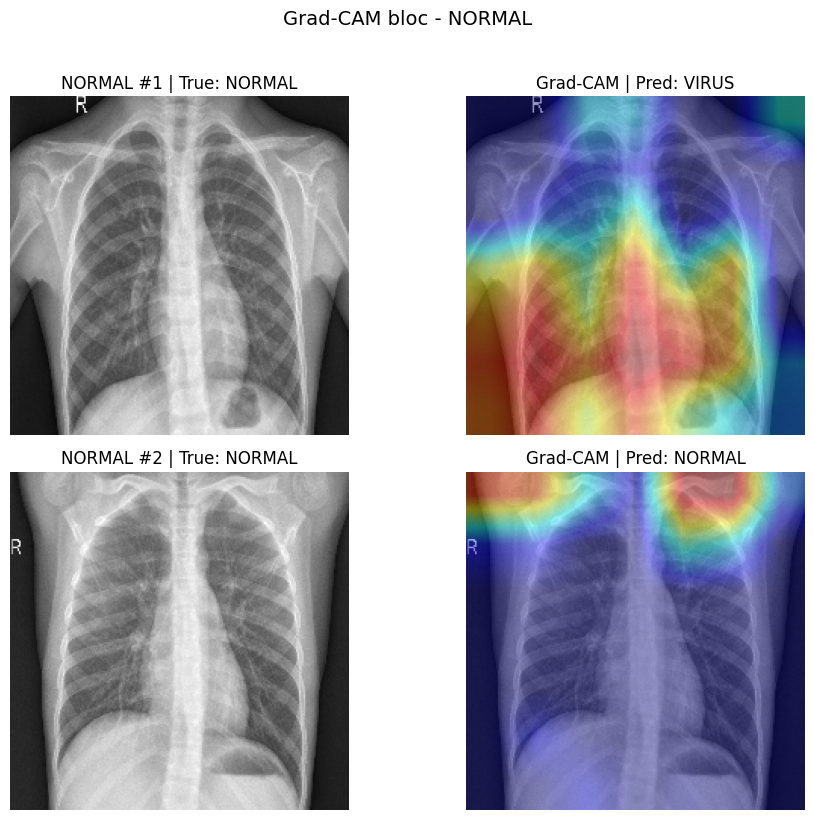

Image en bloc enregistree: gradcam_exports/gradcam_bloc_virus.png


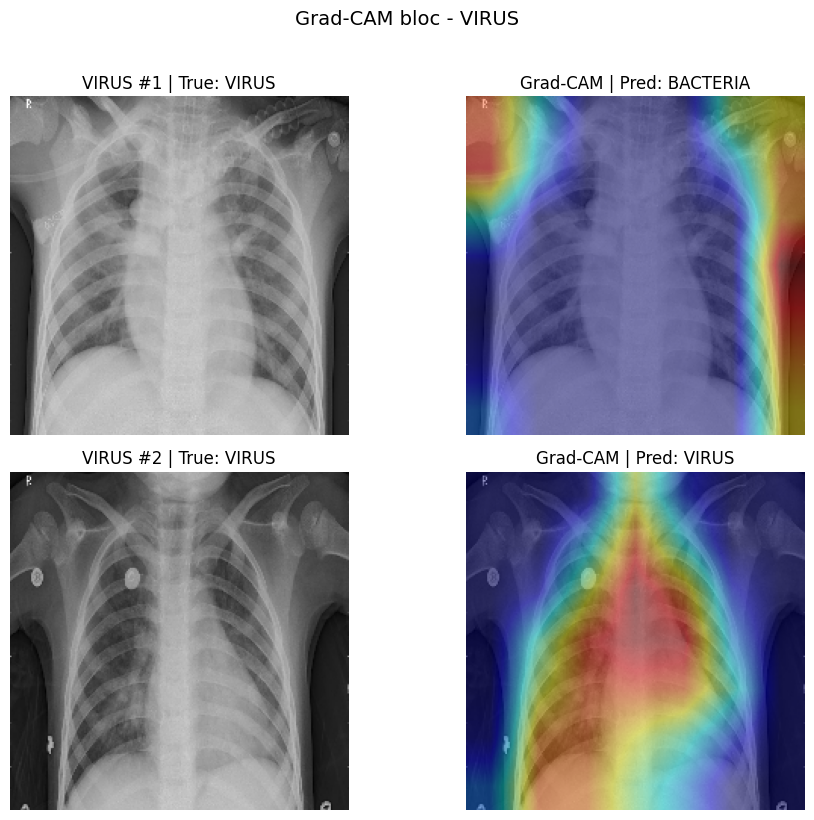

In [53]:
import os

# Visualisation ciblee: NORMAL et VIRUS
target_classes = ["NORMAL", "VIRUS"]
n_per_class = 2  # nombre d'exemples par classe
save_dir = "gradcam_exports"
os.makedirs(save_dir, exist_ok=True)

# Verifier que la cellule Grad-CAM precedente a bien ete executee
required = ["make_gradcam_heatmap", "overlay_gradcam", "best_model", "test_ds", "class_names"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Execute d'abord la cellule 50 (Grad-CAM), il manque: " + ", ".join(missing)
    )

class_to_idx = {name: idx for idx, name in enumerate(class_names)}
target_indices = [class_to_idx[name] for name in target_classes]

picked = {idx: [] for idx in target_indices}

for images, labels in test_ds:
    labels_np = labels.numpy()
    for i in range(images.shape[0]):
        label_idx = int(labels_np[i])
        if label_idx in picked and len(picked[label_idx]) < n_per_class:
            picked[label_idx].append((images[i], label_idx))

    if all(len(picked[idx]) >= n_per_class for idx in target_indices):
        break

# Sauvegarder en bloc: 1 figure par classe, n lignes x 2 colonnes
for target_idx in target_indices:
    target_name = class_names[target_idx]
    samples = picked[target_idx]

    if len(samples) == 0:
        print(f"Aucun exemple trouve pour {target_name}.")
        continue

    n_rows = len(samples)
    fig, axes = plt.subplots(n_rows, 2, figsize=(10, 4 * n_rows))
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row, (img_tensor, true_idx) in enumerate(samples):
        img_array = tf.expand_dims(img_tensor, axis=0)
        heatmap, pred_idx = make_gradcam_heatmap(img_array, best_model)
        superimposed_img = overlay_gradcam(img_array, heatmap)

        axes[row, 0].imshow(img_tensor.numpy().astype(np.uint8))
        axes[row, 0].set_title(f"{target_name} #{row + 1} | True: {class_names[true_idx]}")
        axes[row, 0].axis("off")

        axes[row, 1].imshow(superimposed_img)
        axes[row, 1].set_title(f"Grad-CAM | Pred: {class_names[pred_idx]}")
        axes[row, 1].axis("off")

    fig.suptitle(f"Grad-CAM bloc - {target_name}", fontsize=14, y=1.02)
    fig.tight_layout()

    save_path = os.path.join(save_dir, f"gradcam_bloc_{target_name.lower()}.png")
    fig.savefig(save_path, dpi=200, bbox_inches="tight")
    print(f"Image en bloc enregistree: {save_path}")

    plt.show()